데이터가 많으니까 몇 개 쳐내고 해도 됨. train 이 많아야 함

In [30]:
# 지정된 확장자 명을 갖고 있는 파일들을 한 번에 불러오기 위함
import glob
from PIL import Image
import matplotlib.pyplot as plt

In [31]:
train_images = glob.glob("../Data/fingers/fingers/train/*.png") # 파일 이름 불러오는 거
test_images = glob.glob("../Data/fingers/fingers/test/*.png")

In [32]:
# train data 와 test data 만들기 : 128 * 128 -> 32 * 32

train_input = []
train_target = []
test_input = []
test_target = []

# train data
for image in sorted(train_images):      # sorted : 알파벳 순 정렬
    img = Image.open(image)
    imgResize = img.resize((32, 32), Image.Resampling.LANCZOS)      # 이미지 크기 조정. 그리고 이미지 깨지는 거 방지하기 위해서 뒤에 붙임
    train_input.append(imgResize)
    train_target.append(image[-6:-4])       # 파일 이름의 오른쪽 6번째 ~ 5번째 (ex_0L) 가져옴

# test data
for image in sorted(test_images):
    img = Image.open(image)
    imgResize = img.resize((32, 32), Image.Resampling.LANCZOS)
    test_input.append(imgResize)
    test_target.append(image[-6:-4])

In [33]:
# Target Data 확인
print(train_target[:5])
print(test_target[:5])

['0L', '0L', '2L', '0L', '5L']
['5L', '5L', '3R', '5L', '5L']


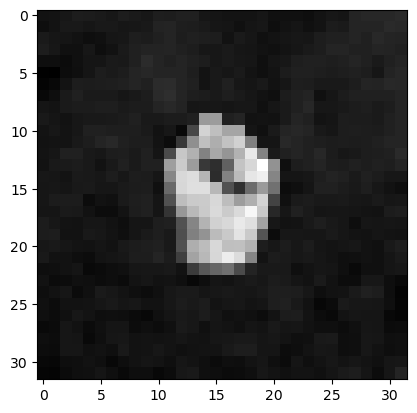

In [34]:
# train 의 이미지 확인
plt.imshow(train_input[0], cmap='gray')
plt.show()

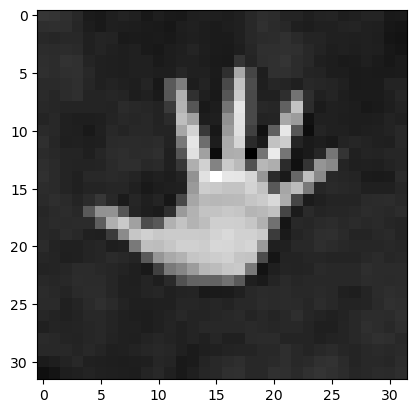

In [35]:
# test 의 이미지 확인
plt.imshow(test_input[0], cmap='gray')
plt.show()

In [36]:
import numpy as np

In [37]:
# train data 만들기. (18000 * 32 * 32) 이미지를 깡으로 numpy 배열에 넣을 순 없음. 변경해줘야 함.
tempData = np.zeros(
    18000 * 32 * 32,
    dtype=np.int32
).reshape(18000, 32, 32)
# tempData.shape

i = 0
for image in train_input:
    img = np.array(image, dtype=np.int32)
    tempData[i,:,:] = img       # 18000 쪽에 하나씩 이미지 넣음
    i+=1

train_input = tempData.copy()

In [38]:
# test data 만들기. (3600 * 32 * 32) 이미지를 깡으로 numpy 배열에 넣을 순 없음. 변경해줘야 함.
tempData = np.zeros(
    3600 * 32 * 32,
    dtype=np.int32
).reshape(3600, 32, 32)

i = 0
for image in test_input:
    img = np.array(image, dtype=np.int32)
    tempData[i,:,:] = img       # 18000 쪽에 하나씩 이미지 넣음
    i+=1

test_input = tempData.copy()

In [39]:
# 배열 크기 확인
print(train_input.shape, test_input.shape)

(18000, 32, 32) (3600, 32, 32)


In [40]:
label_to_int = {        # Target 은 이렇게 써도 됨
    '0R' : 0,
    "1R" : 1,
    "2R" : 2,
    "3R" : 3,
    "4R" : 4,
    "5R" : 5,
    "0L" : 6,
    "1L" : 7,
    "2L" : 8,
    "3L" : 9,
    "4L" : 10,
    "5L" : 11
}

In [41]:
# Train target 숫자로 변경
temp = []
for label in train_target:
    temp.append(label_to_int[label])
train_target = temp.copy()

In [42]:
# Test target 숫자로 변경
temp = []
for label in test_target:
    temp.append(label_to_int[label])
test_target = temp.copy()

In [43]:
# Target 도 numpy 배열로 변경
train_target = np.array(train_target)
test_target = np.array(test_target)

In [44]:
print(train_target[:5])
print(test_target[:5])

[ 6  6  8  6 11]
[11 11  3 11 11]


In [45]:
print(train_input.shape)
print(train_target.shape)

(18000, 32, 32)
(18000,)


#### CNN

In [46]:
from sklearn.model_selection import train_test_split

train = train_input.reshape(-1, 32, 32, 1) / 255.0     # 선형 회귀 출발이기 때문에 무조건 정규화 해야함. +) 정규화 해야 좋은지도 비교하면 좋음 (? 아마)
test_scaled = test_input.reshape(-1, 32, 32, 1) / 255.0

train_scaled, val_scaled, train_target, val_target = \
    train_test_split(
        train,
        train_target,
        test_size=0.2,
        random_state=42
    )

In [47]:
# 크기 확인
print(train_scaled.shape, test_scaled.shape)
print(train_target.shape, test_target.shape)

(14400, 32, 32, 1) (3600, 32, 32, 1)
(14400,) (3600,)


In [48]:
from tensorflow import keras

In [50]:
# 1번째 CNN 층
model = keras.Sequential()
model.add(
    keras.layers.Conv2D(
        32,
        kernel_size=3,  # 보통 정사각형으로 구성 (3,3)
        activation='relu',
        padding='same',  # 원본 이미지 크기과 같게  <=> valid
        input_shape=(32, 32, 1)
    )           # Conv2D(필터 갯수, 필터의 구성, 활성화 함수, padding, 형태)
)

In [51]:
model.add(
    keras.layers.MaxPooling2D(2)    # 2*2 max pooling
)

In [52]:
# 2번째 CNN 층
model.add(
    keras.layers.Conv2D(
        64,     # => 바뀜
        kernel_size=3,  # 보통 정사각형으로 구성 (3,3)
        activation='relu',
        padding='same',  # 원본 이미지 크기과 같게  <=> valid
    )
)
model.add(
    keras.layers.MaxPooling2D(2)    # 2*2 max pooling
)

In [53]:
# 입력층
model.add(
    keras.layers.Flatten()  # 평평하게 1차원으로 바꿔라
)

# 은닉층
model.add(
    keras.layers.Dense(100, activation='relu', name='hidden')
)

# Drop out 층
model.add(keras.layers.Dropout(0.5))

# 출력층
model.add(
    keras.layers.Dense(12, activation='softmax', name='output')
)

In [54]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden (Dense)                  │ (None, 100)            │       409,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 12)             │         1,212 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 429,728 (1.64 MB)

 Trainable params: 429,728 (1.64 MB)

 Non-trainable params: 0 (0.00 B)

In [55]:
# compile
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# 모델의 저장
model.save('../Data/best_cnn_model_fingers.keras')

In [56]:
checkpoint_cb = keras.callbacks.ModelCheckpoint('../Data/best_cnn_model_fingers.keras', save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)

In [57]:
history = model.fit(
    train_scaled,
    train_target,
    epochs=20,
    validation_data=(val_scaled, val_target),
    callbacks=[checkpoint_cb, early_stopping_cb]
)

Epoch 1/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.7935 - loss: 0.6225 - val_accuracy: 0.9931 - val_loss: 0.0250
Epoch 2/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9670 - loss: 0.0980 - val_accuracy: 0.9989 - val_loss: 0.0048
Epoch 3/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9769 - loss: 0.0630 - val_accuracy: 1.0000 - val_loss: 0.0017
Epoch 4/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9826 - loss: 0.0461 - val_accuracy: 1.0000 - val_loss: 9.6148e-04
Epoch 5/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9852 - loss: 0.0400 - val_accuracy: 1.0000 - val_loss: 5.9398e-04
Epoch 6/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9862 - loss: 0.0351 - val_accuracy: 1.0000 - val_loss: 3.3721e-04
Epoch 7/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9883 - loss: 0.0307 - val_accuracy: 1.0000 - val_loss: 6.8599e-05
Epoch 8/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9897 - loss: 0.027

In [60]:
# 평가
print('train : ', model.evaluate(train_scaled, train_target))
print('val : ', model.evaluate(val_scaled, val_target))
print('test : ', model.evaluate(test_scaled, test_target))

450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.0000 - loss: 3.5504e-05
train :  [3.550365727278404e-05, 1.0]
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 6.8599e-05
val :  [6.859867426101118e-05, 1.0]
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 5.3181e-05
test :  [5.3181032853899524e-05, 1.0]


In [61]:
pred = model.predict(test_scaled)
print("test label", test_target[:10])
print("pred max", np.argmax(pred[:10], axis=1))     # argmax : 예측값 중 최대값의 index

113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
test label [11 11  3 11 11  4  2  4 11  4]
pred max [11 11  3 11 11  4  2  4 11  4]


In [64]:
# test_data 의 0번 예측값을 확인
print("예측값 : ", np.argmax(pred[0]))

int_to_label = {v: k for k, v in label_to_int.items()}
print(int_to_label[np.argmax(pred[0])])

예측값 :  11
5L
